In [1]:
import tensorflow as tf
# import numpy as np

# ----------------------------------------------------
# 1. โค้ดตั้งค่า GPU ต้องอยู่ตรงนี้
# ----------------------------------------------------
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # เปิดใช้งาน Memory Growth
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU Memory Growth ถูกเปิดใช้งานเรียบร้อยแล้ว")
    except RuntimeError as e:
        print(e) 
        
# ----------------------------------------------------
# 2. จากนั้นจึงเริ่มสร้างโมเดล หรือโหลดข้อมูล
# ----------------------------------------------------
# model = tf.keras.models.Sequential(...) # ปลอดภัยที่จะเรียกใช้โมเดล
# history = model.fit(...)

2025-11-16 08:08:20.017577: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-16 08:08:20.084290: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-16 08:08:20.125399: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-16 08:08:20.135344: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-16 08:08:20.177716: I tensorflow/core/platform/cpu_feature_guar

GPU Memory Growth ถูกเปิดใช้งานเรียบร้อยแล้ว


I0000 00:00:1763280501.613008   19453 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763280501.894201   19453 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763280501.894262   19453 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import numpy as np
import cv2
from os import listdir
from os.path import isfile, join
from tqdm import tqdm
import tensorflow as tf
from keras.models import Sequential , load_model
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from keras.applications import MobileNetV2
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)


Num GPUs Available:  1
2.17.0


(<Axes: >, <matplotlib.image.AxesImage at 0x7ff2a2613770>)

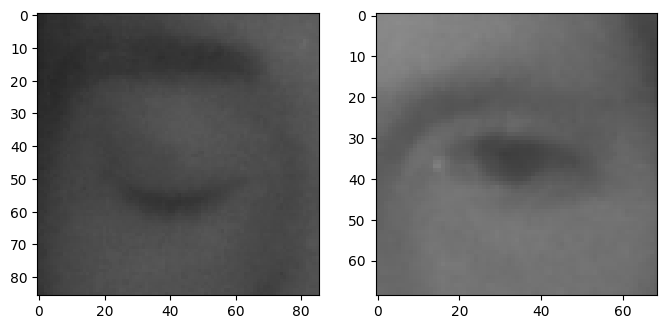

In [3]:
img1 = cv2.imread('assets/images/train/Closed/_1.png')
img1 = cv2.cvtColor(img1 , cv2.COLOR_BGR2RGB)

img2 = cv2.imread('assets/images/train/Open/ex_img_40851.png')
img2 = cv2.cvtColor(img2 , cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(121),plt.imshow(img1)
plt.subplot(122),plt.imshow(img2)

In [4]:
width = 128
num_classes = 2
trainpath = 'assets/images/train/'
testpath = 'assets/images/test/'
# testExPath = 'img/Test/'
trainImg = [trainpath+f for f in listdir(trainpath)]
testImg = [testpath+f for f in listdir(testpath)]
# testExImg = [testExPath + f for f in listdir(testExPath)]
img_size = 128
batch_size = 16

In [5]:
def img2data(path):
    rawImgs = []
    labels = []
    i=0
    for imagePath in (path):
        print(imagePath)
        print(trainImg)
        for item in tqdm(listdir(imagePath)):
            
            if i == 8000 and  (np.where(imagePath == trainpath) or np.where(imagePath == testpath)):
                return rawImgs, labels
                        
            file = join(imagePath, item)
            if file[-1] =='g':
                img = cv2.imread(file , cv2.COLOR_BGR2RGB)
                img = cv2.resize(img ,(width,width))
                rawImgs.append(img)
                
                l = imagePath.split('/')[-1]
                if l == 'Closed':
                    labels.append([1,0])         
                elif l == 'Open':
                    labels.append([0,1])
                i+=1    
            
    return rawImgs, labels

In [6]:
x_train, y_train = img2data(trainImg)
x_test, y_test = img2data(testImg)
# x_test_ex , y_test_ex = img2data(testExImg)

assets/images/train/Open
['assets/images/train/Open', 'assets/images/train/Closed', 'assets/images/train/.ipynb_checkpoints']


 38%|███▊      | 7788/20345 [00:03<00:05, 2146.22it/s]/tmp/ipykernel_64308/3192207342.py:10: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  if i == 8000 and  (np.where(imagePath == trainpath) or np.where(imagePath == testpath)):
 39%|███▉      | 8000/20345 [00:03<00:06, 2017.81it/s]


assets/images/test/Open
['assets/images/train/Open', 'assets/images/train/Closed', 'assets/images/train/.ipynb_checkpoints']


100%|██████████| 546/546 [00:00<00:00, 1277.32it/s]


assets/images/test/Closed
['assets/images/train/Open', 'assets/images/train/Closed', 'assets/images/train/.ipynb_checkpoints']


100%|██████████| 403/403 [00:00<00:00, 1190.35it/s]


assets/images/test/.ipynb_checkpoints
['assets/images/train/Open', 'assets/images/train/Closed', 'assets/images/train/.ipynb_checkpoints']


0it [00:00, ?it/s]


In [7]:
x_train = np.array([cv2.resize(cv2.cvtColor(image,cv2.COLOR_BGR2RGB), (img_size, img_size)) for image in x_train])
y_train = np.array(y_train)
x_test = np.array([cv2.resize(cv2.cvtColor(image,cv2.COLOR_BGR2RGB), (img_size, img_size)) for image in x_test])
y_test = np.array(y_test)
# x_test_ex = np.array([cv2.resize(cv2.cvtColor(image,cv2.COLOR_BGR2RGB), (img_size, img_size)) for image in x_test_ex])
# y_test_ex = np.array(y_test_ex)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
# x_test_ex = x_test_ex.astype('float32')
x_train /= 255
x_test /= 255
# x_test_ex /= 255

In [8]:
x_test.shape, y_test.shape,x_train.shape, y_train.shape

((949, 128, 128, 3), (949, 2), (8000, 128, 128, 3), (8000, 2))

In [9]:
# train_generator = ImageDataGenerator(rescale=1/255, zoom_range=0.2, horizontal_flip=True, rotation_range=30)
# test_generator = ImageDataGenerator(rescale=1/255)

# train_generator = train_generator.flow(x_train, y_train, shuffle=False)
# test_generator = test_generator.flow(x_test, y_test, shuffle=False)

In [10]:
model = Sequential()

model.add(Conv2D(256, (3, 3), activation="relu", input_shape=(128,128,3)))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(256, activation="relu"))
model.add(Dense(2, activation="softmax"))

model.compile(loss="categorical_crossentropy", metrics=["accuracy"], optimizer="adam")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1763020571.544764   64308 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763020571.544929   64308 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763020571.544963   64308 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1763020571.723488   64308 cuda_executor.cc:1001] 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,586 (2.20 MB)

 Trainable params: 575,586 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    x=x_train,                 # Pass training features as 'x'
    y=y_train,                 # Pass training labels as 'y'
    batch_size=8,
    epochs=50,
    validation_data=(x_test, y_test), # validation_data remains a tuple (X_val, Y_val)
    shuffle=True,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)]
)

Epoch 1/50


I0000 00:00:1763020576.544050   64666 service.cc:146] XLA service 0x7ff190004f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763020576.544100   64666 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0
2025-11-13 07:56:16.602575: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-13 07:56:17.074813: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
2025-11-13 07:56:18.649098: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' i

   9/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8821 - loss: 0.3817

2025-11-13 07:56:19.140872: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_4', 72 bytes spill stores, 72 bytes spill loads

I0000 00:00:1763020579.153051   64666 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 997/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9972 - loss: 0.0109

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
2025-11-13 07:56:34.853825: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.09GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9972 - loss: 0.0109 - val_accuracy: 0.5753 - val_loss: 510.2726
Epoch 2/50
   1/1000 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 1.0000 - loss: 0.0000e+00

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5753 - val_loss: 510.2726
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5753 - val_loss: 510.2726
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5753 - val_loss: 510.2726
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5753 - val_loss: 510.2726
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5753 - val_loss: 510.2726
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5753 - val_loss: 510.2726
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5753 - val_loss: 510.2726


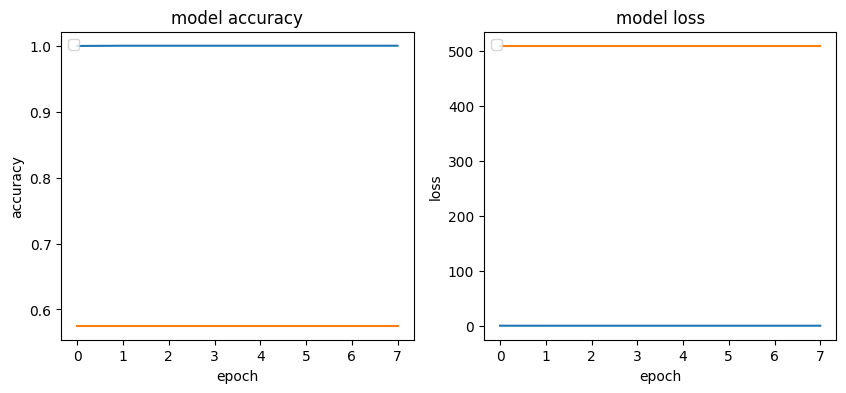

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(121),
plt.title('model accuracy');plt.ylabel('accuracy');plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.plot(history.history['accuracy']);plt.plot(history.history['val_accuracy'])

plt.subplot(122)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.plot(history.history['loss']);plt.plot(history.history['val_loss'])

model.save('eye_status_model1.keras')

In [21]:
# If you have a saved model on disk you can use:
# converter = tf.lite.TFLiteConverter.from_saved_model("model_saved")


model = tf.keras.saving.legacy.load_model(
    "model/good/MobileNetV1Model.keras",
    compile=False
)

# Convert directly from the in-memory Keras model:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
open("model_int8.tflite", "wb").write(tflite_model)

AttributeError: module 'tf_keras.api._v2.keras.saving' has no attribute 'legacy'